##  A quantum algorithm applies a specific sequence of operations to our qubits to change their quantum state in a controlled manner.
### A common way to visually represent those algorithms is what's called the quantum circuit model which is a diagram that shows the sequence of steps in a quantum computation.

---


# Characteristic of Quantum Logic Gates

---
- The matrices we use to describe Quantum logic gates are unitary.
  - A unitary matrix is a square matrix such that if we multiply it by its conjugate transpose we get the identity matrix $I$.
  - This is significant to quantum computing because a unitary matrix will preserve the magnitude or norm when we multiply it against a state vector.
  - If we multiply a unitary matrix operator with an arbitrary state vector ket, the magnitude of the resulting state vector will be the same as the magnitude of the original state vector ket.
- Preserving that magnitude is essential because the quantum state vector should always have a magnitude of one, which is the sum of the probabilities for every possible outcome.
- Quantum logic gates are reversible. This means that the state of a qubit after applying a known quantum gate can be restored by applying the inverse operation to that qubit.
  - This method is used to determine what the quantum state was before it went through that gate, effectively undoing or reversing the operation.

# Unitary Matrix

* A square matrix $U$ such that $U^\dagger U = UU^\dagger = I$
* Preserves the magnitude when multiplied with a state vector

$$ \| U|\psi\rangle \| = \| |\psi\rangle \| $$



# Pauli Gates
---

* Quantum logic gates that operate on a single qubit
* Rotation of $\pi$ radians around a major axis of the Bloch sphere

$$
\boxed{X} = \sigma_X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \quad\quad
\boxed{Y} = \sigma_Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} \quad\quad
\boxed{Z} = \sigma_Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
$$

# Pauli-X Gate
---

* Single-qubit gate that swaps $|0\rangle$ and $|1\rangle$
* $|0\rangle \rightarrow |1\rangle$
* $|1\rangle \rightarrow |0\rangle$
* Quantum equivalent of the NOT gate for classical computers

### Action of Pauli-X on an Arbitrary Superposition State

**Original State Vector:**
$$ |\psi\rangle = \color{cornflowerblue}{\alpha}|0\rangle + \color{lightcoral}{\beta}|1\rangle $$

$$\Downarrow \quad \text{Apply Pauli-X (flip states/coefficients)}$$

**Resulting State Vector:**
$$ X|\psi\rangle = \color{cornflowerblue}{\alpha}|1\rangle + \color{lightcoral}{\beta}|0\rangle $$

 The result will be a state in which the alpha now applies to Ket one and beta is a probability amplitude of ket zero. Swapping or inverting the two basis states in this expression.

# Pauli-X Matrix Representation

* $X|0\rangle = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 1 \end{bmatrix} = |1\rangle$
*
* $X|1\rangle = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 1 \\ 0 \end{bmatrix} = |0\rangle$
*
* $X|\psi\rangle = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} \color{cornflowerblue}{\alpha} \\ \color{lightcoral}{\beta} \end{bmatrix} = \begin{bmatrix} \color{lightcoral}{\beta} \\ \color{cornflowerblue}{\alpha} \end{bmatrix}$


In [139]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

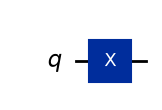

In [140]:
circuit = QuantumCircuit(1)
circuit.x(0)
circuit.draw(output='mpl')

In [141]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

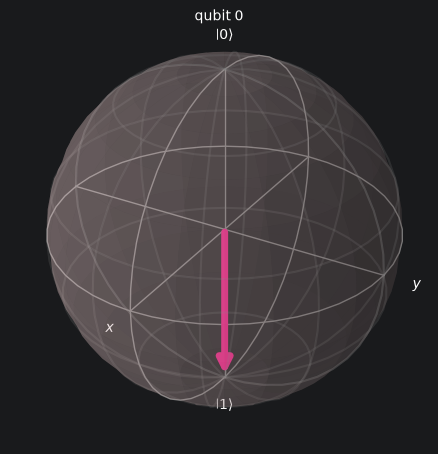

In [142]:
plot_bloch_multivector(statevector)

   ┌───┐
q: ┤ X ├
   └───┘


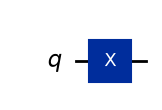

In [143]:
circuit = QuantumCircuit(1)
circuit.x(0)
print(circuit)
circuit.draw(output='mpl')

In [144]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

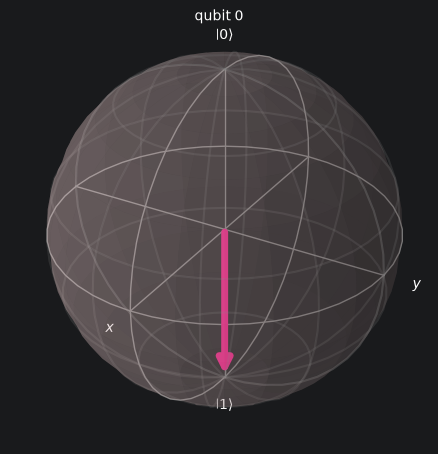

In [145]:
plot_bloch_multivector(statevector)

 # That demonstrates how the Pauli-x gate can flip a qubit between its two basis states.

   ┌─────────┐┌───┐
q: ┤ Rx(π/4) ├┤ X ├
   └─────────┘└───┘


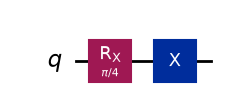

In [146]:
circuit = QuantumCircuit(1)
circuit.rx(pi/4, 0)
circuit.x(0)
print(circuit)
circuit.draw(output='mpl')

In [147]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

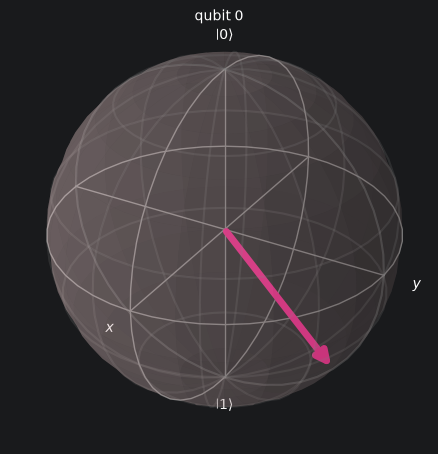

In [148]:
plot_bloch_multivector(statevector)

###  Using the Pauli-x gate, I flipped the probability amplitude so now there's a higher probability of measuring this qubit as one, than measuring it as zero.

# Pauli-Y Gate
---

The Pauli-Y gate is most commonly represented as a two by two matrix shown here with negative $i$ in the top right corner and positive $i$ in the bottom left corner. If we apply that gate to the ket zero state, we get an output vector whose first element is zero and the second element is $i$. Because the first element is zero, we can easily factor out that $i$ which shows us the result of using the Pauli-Y gate on ket zero is $i$ times ket one. So in addition to flipping the bit, the Pauli-Y gate also gave this state a phase factor of $i$.

$$Y|0\rangle = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ i \end{bmatrix} = i\begin{bmatrix} 0 \\ 1 \end{bmatrix} = i|1\rangle$$

 If we calculate the measurement probabilities for that resulting state, we can see that the probability of measuring an outcome of zero is zero,
 $$P(Y|0\rangle = |0\rangle) = |0|^2 = 0$$
 and the probability of measuring a one is the absolute value of I squared, which equals one.
$$P(Y|0\rangle = |1\rangle) = |i|^2 = 1$$


 Since those are the exact same outcome probabilities as the regular one state, which means there is no physically observable differences between ket one and I times ket one. Then imaginary I on the front is just a global phase factor.

 So we see that applying the Pauli-Y operation on one of our two basis states flips the bit and applies a global phase.

### Matrix representation
---

If we use the Pauli-Y gate on an arbitrary quantum state with complex coefficients alpha and beta, the resulting vector has negative $i$ times beta as the first element and $i$ times alpha as the second element. We can factor out the $i$ from that vector, but we cannot factor out the negative sign from beta.

$$Y|\psi\rangle = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} \begin{bmatrix} \color{dodgerblue}\alpha \\ \color{crimson}\beta \end{bmatrix} = \begin{bmatrix} -i\color{crimson}\beta \\ i\color{dodgerblue}\alpha \end{bmatrix} = i\begin{bmatrix} -\color{crimson}\beta \\ \color{dodgerblue}\alpha \end{bmatrix} = i(\color{dodgerblue}\alpha|1\rangle - \color{crimson}\beta|0\rangle)$$

 Written out using direct notation, this is the resulting state vector:
$$|\psi\rangle = \color{dodgerblue}\alpha|0\rangle + \color{crimson}\beta|1\rangle$$



This was our starting quantum state, $|\psi\rangle$, and this is the result after using the Pauli-Y gate. The first thing to notice is that we've flipped the bits by swapping the two basis states, zero and one. Next is the $i$ that we factored out which represents a global phase factor. $i$ is equal to $e^{i\frac{\pi}{2}}$. So the $i$ on the front of this expression corresponds to a global phase factor of $\pi/2$. Finally, we have the factor of negative one which is equivalent to $e^{i\pi}$. That corresponds to a relative phase change of $\pi$ radians or 180 degrees.

$$Y|\psi\rangle = i(\color{dodgerblue}\alpha|1\rangle - \color{crimson}\beta|0\rangle)$$

Where:
* **Global Phase:** $i = e^{i\frac{\pi}{2}}$
* **Relative Phase Flipped:** $-1 = e^{i\pi}$

So in addition to flipping this bit which swaps our quantum state between the top half and bottom half of the block sphere, the Pauli-Y gate also flips its relative phase which moves the state between the front side and the backside of the Bloch sphere.

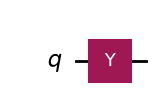

In [149]:
circuit = QuantumCircuit(1)
circuit.y(0)
circuit.draw(output='mpl')

In [150]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector, prefix="\\text{Statevector = }\n")

<IPython.core.display.Latex object>

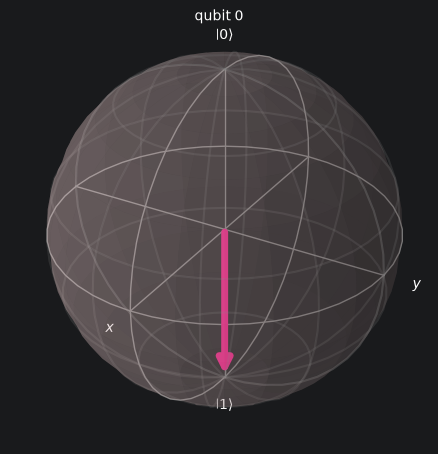

In [151]:
plot_bloch_multivector(statevector)

Using the Pauli-X and Y gates on the zero basis state produces mathematically different results with differences in global phase, but there are physically indistinguishable from each other, and both represented by the same point on the bottom of the Bloch sphere whose measurement outcome will always be 1.

### How the Pauli-Y gate affects a more interesting superposition state
---


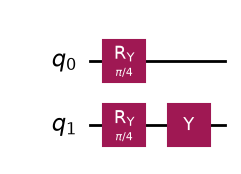

In [152]:
circuit = QuantumCircuit(2)
circuit.ry(pi / 4, [0,1])
circuit.y(1) # Applied only to the second qubit
circuit.draw(output='mpl')

In [153]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector, prefix="\\text{Statevector = }\n")

<IPython.core.display.Latex object>

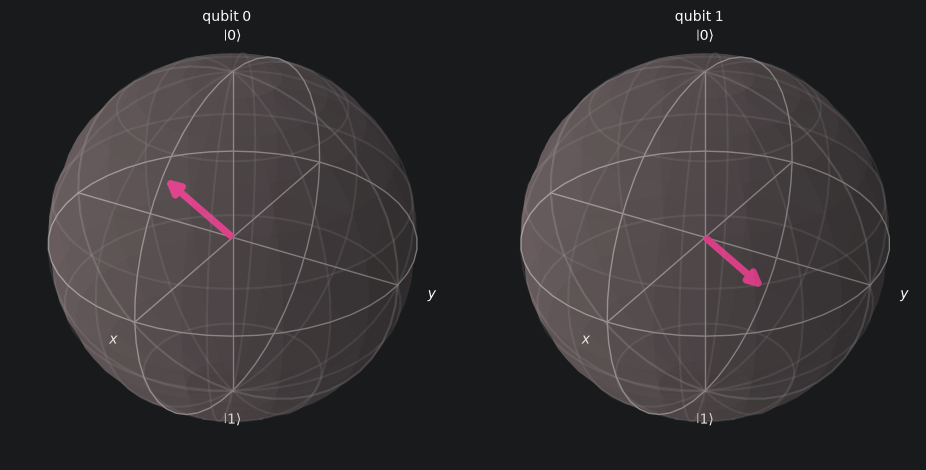

In [154]:
plot_bloch_multivector(statevector)

We can see side by side how the Pauli-Y gate changes that superposition going from the state shown on the left Bloch sphere with qubit 0 to the right Bloch sphere with qubit 1

# Pauli-Z Gate
---

Pauli-Z gate corresponds to a rotation of $\pi$ radians around the Z-axis of the Bloch sphere

### Impact of the Pauli-Z Gate on the Bloch Sphere

* Preservation of Latitude: Unlike the Pauli-X and Pauli-Y gates which flip the state between the top and bottom halves of the Bloch sphere, the Pauli-Z gate keeps the quantum state on the same half.
* Constant Measurement Probabilities: Because the state remains at the same latitude, the probabilities of measuring $\vert{}0\rangle$ or $\vert{}1\rangle$ remain completely unchanged.
* Phase Flip Transformation: The Pauli-Z gate flips the phase of the quantum state instead of its bit value.
* Bloch Sphere Rotation: This phase flip geometrically rotates the state vector by $\pi$ radians around the Z-axis, moving it from the front side of the Bloch sphere to the back side.





## Pauli-Z Gate Matrix Representation

The Pauli-Z gate acts as a phase flip operator. It is represented by a diagonal two-by-two matrix with a positive one in the top-left entry and a negative one in the bottom-right entry.

$$Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$

### Action on Computational Basis States

Let's take a look at the math behind that. The Pauli-Z operator is represented as a two by two matrix shown here, with one in the top left corner and negative one in the bottom right.

When we use the operator on the zero basis state, the result is $|0\rangle$. The Pauli-Z gate has absolutely no effect on it:

$$Z|0\rangle = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 1 \\ 0 \end{bmatrix} = |0\rangle$$

However, when we apply it to $|1\rangle$, that negative one from the Pauli-Z matrix gets picked up, which gives us a result of negative $|1\rangle$:

$$Z|1\rangle = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ -1 \end{bmatrix} = -|1\rangle$$

That negative factor out front is a global phase factor, and there isn't any distinguishable difference between negative $|1\rangle$ and positive $|1\rangle$. They both represent the same state on the bottom of the Bloch sphere.

So, using the Pauli-Z gate on either of the standard basis states doesn't really change anything. For the Pauli-Z gate to have any effect, our qubit has to be in a state that's somewhere not along the Z-axis.

### Action on an Arbitrary Quantum State

If we use the Pauli-Z operator on a quantum state with complex coefficients $\alpha$ and $\beta$, the result is a state in which the $\alpha$ coefficient is unchanged, but the sign of the $\beta$ coefficient is negated. This corresponds to flipping the qubit's relative phase by rotating it $\pi$ radians around the Z-axis:

$$Z|\psi\rangle = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} \color{dodgerblue}\alpha \\ \color{crimson}\beta \end{bmatrix} = \begin{bmatrix} \color{dodgerblue}\alpha \\ -\color{crimson}\beta \end{bmatrix} = \color{dodgerblue}\alpha|0\rangle - \color{crimson}\beta|1\rangle$$

* **Relative Phase Flipped:** The negative sign acting on the $|1\rangle$ component represents a relative phase flip, where:

<div align="center">
  <span style="color: dodgerblue;">$\alpha|0\rangle$</span> $= e^{i\pi}$
</div>



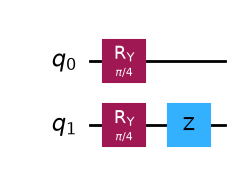

In [155]:
circuit = QuantumCircuit(2)
circuit.ry(pi / 4, [0, 1])
circuit.z(1)  # Applied only to the second qubit
circuit.draw(output='mpl')

In [156]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector, prefix="\\text{Statevector = }\n")

<IPython.core.display.Latex object>

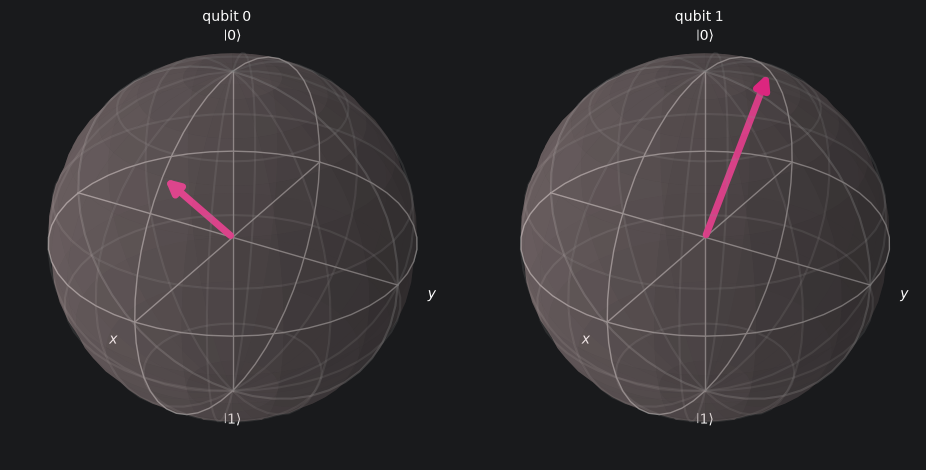

In [157]:
plot_bloch_multivector(statevector)

# Summary
---

When applied to a single qubit, the actions of the Pauli gates can be summarized as follows:

* **Pauli-X Gate (Bit Flip):** Swaps the measurement probabilities between the two basis states.
  $$X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$

* **Pauli-Y Gate (Bit Flip and Phase Flip):** Flips both the bit and the relative phase simultaneously.
  $$Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}$$

* **Pauli-Z Gate (Phase Flip):** Only flips the relative phase of the qubit, leaving its probability distribution completely unchanged.
  $$Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$
